**Handle Imports**

In [52]:
import warnings
import sys 
if not sys.warnoptions:
    warnings.simplefilter("ignore")
import numpy as np
import nibabel as nib
from nilearn.input_data import NiftiMasker,  MultiNiftiMasker
from scipy import stats
from sklearn import preprocessing
import matplotlib.pyplot as plt 
import seaborn as sns 
import os
import pandas as pd
import glob
import json
from brainiak import image, io
import brainiak.eventseg.event
import torch
from nilearn import datasets, image as nli_image
from scipy import stats
from scipy.stats import zscore
from sklearn.model_selection import LeaveOneOut
import matplotlib.patches as patches



torch.set_grad_enabled(False)

from transformers import AutoTokenizer, AutoModelForCausalLM
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler


%matplotlib inline 

sns.set(palette = "colorblind", style = 'white', context = 'notebook', rc = {"lines.linewidth": 2.5})

**Set up paths to load data**

In [33]:
#Set up paths
bids_dir   = '/home/NEU480/datasets/narratives'
task       = 'milkyway'
space      = 'MNI152NLin2009cAsym'
res        = 'native'
variant = 'vodka'   # ← change this to switch between 'original', 'synonyms', 'vodka'
TR=1.5
# All paths relative to bids_dir
paths = {
    'audio'      : os.path.join(bids_dir, 'stimuli'),
    'transcript' : os.path.join(bids_dir, 'stimuli', 'transcripts'),
    'gentle'     : os.path.join(bids_dir, 'stimuli', 'gentle'),
    'whisperx'   : os.path.join(bids_dir, 'stimuli', 'whisperx'),
    'afni'       : os.path.join(bids_dir, 'derivatives', 'afni-nosmooth'),
    'fmriprep'   : os.path.join(bids_dir, 'derivatives', 'fmriprep'),
    'participants': os.path.join(bids_dir, 'participants.tsv'),
}

# Subjects for this task — add/remove here, nowhere else
SUBJECTS = ['sub-023', 'sub-030', 'sub-032', 'sub-038', 'sub-052']

print(f"Task: {task} | Subjects: {SUBJECTS}")

Task: milkyway | Subjects: ['sub-023', 'sub-030', 'sub-032', 'sub-038', 'sub-052']


**Get file paths for each subject's mask/bold data**

In [34]:
#Make fucntions for getting file paths
def get_bold_path(subject):
    fname = (f"{subject}_task-{task}_space-{space}"
             f"_res-{res}_desc-clean_bold.nii.gz")
    return os.path.join(paths['afni'], subject, 'func', fname)

def get_mask_path(subject):
    fname = (f"{subject}_task-{task}_space-{space}"
             f"_res-{res}_desc-brain_mask.nii.gz")
    return os.path.join(paths['fmriprep'], subject, 'func', fname)

# Quick check — print existence for each subject
for sub in SUBJECTS:
    bold_exists = os.path.exists(get_bold_path(sub))
    mask_exists = os.path.exists(get_mask_path(sub))
    print(f"{sub}  BOLD: {'yes' if bold_exists else 'no, MISSING'}  "
          f"Mask: {'yes' if mask_exists else 'no, MISSING'}")

sub-023  BOLD: yes  Mask: yes
sub-030  BOLD: yes  Mask: yes
sub-032  BOLD: yes  Mask: yes
sub-038  BOLD: yes  Mask: yes
sub-052  BOLD: yes  Mask: yes


In [35]:
bold_imgs  = {}   # subject → nibabel Nifti1Image
bold_hdrs  = {}   # subject → header
brain_masks = {}  # subject → boolean mask array

missing = []

for sub in SUBJECTS:
    bold_path = get_bold_path(sub)
    mask_path = get_mask_path(sub)

    if not os.path.exists(bold_path):
        print(f"[SKIP] {sub}: BOLD not found at {bold_path}")
        missing.append(sub)
        continue
    if not os.path.exists(mask_path):
        print(f"[SKIP] {sub}: mask not found at {mask_path}")
        missing.append(sub)
        continue

    bold_imgs[sub]   = nib.load(bold_path)
    bold_hdrs[sub]   = bold_imgs[sub].header
    brain_masks[sub] = io.load_boolean_mask(mask_path)

    n_trs = bold_imgs[sub].shape[-1]
    tr    = bold_hdrs[sub].get_zooms()[-1]
    print(f"{sub}  shape: {bold_imgs[sub].shape}  TRs: {n_trs}  TR: {tr}s")

loaded = [s for s in SUBJECTS if s not in missing]
print(f"\nLoaded {len(loaded)}/{len(SUBJECTS)} subjects")

sub-023  shape: (65, 77, 49, 297)  TRs: 297  TR: 1.5s
sub-030  shape: (65, 77, 49, 297)  TRs: 297  TR: 1.5s
sub-032  shape: (65, 77, 49, 297)  TRs: 297  TR: 1.5s
sub-038  shape: (65, 77, 49, 297)  TRs: 297  TR: 1.5s
sub-052  shape: (65, 77, 49, 297)  TRs: 297  TR: 1.5s

Loaded 5/5 subjects


In [36]:
#Preset dict
bold_imgs_trim = {}

#Loop thru subjects
for sub in loaded:
    #Extract data
    img = bold_imgs[sub]
    data = img.get_fdata()

    # remove first 14 TRs and last 9, remove NaNs
    data_trim = data[:, :, :, 14:-9]
    data_trim = np.nan_to_num(data_trim)
    
    # create new NIfTI
    img_trim = nib.Nifti1Image(data_trim, affine=img.affine)

    #Store again in bold_imgs_trim
    bold_imgs_trim[sub] = img_trim

In [37]:
# ── Load Schaefer atlas and select DMN + early sensory parcels ────────
schaefer_dir      = '/home/ph0967/nilearn_data/schaefer_2018'
atlas_img_path    = f'{schaefer_dir}/Schaefer2018_100Parcels_7Networks_order_FSLMNI152_2mm.nii.gz'
atlas_labels_path = f'{schaefer_dir}/Schaefer2018_100Parcels_7Networks_order.txt'

atlas_img = nib.load(atlas_img_path)
atlas_df  = pd.read_csv(
    atlas_labels_path, sep='\t', header=None,
    names=['index', 'name', 'r', 'g', 'b', 'a']
)

# Resample atlas to subject bold space
ref_img       = bold_imgs_trim[loaded[0]]
atlas_res     = nli_image.resample_to_img(atlas_img, ref_img, interpolation='nearest')
atlas_data    = atlas_res.get_fdata().astype(int)

# Select parcels by network
dmn_parcels = atlas_df[atlas_df['name'].str.contains('Default')]
vis_parcels = atlas_df[atlas_df['name'].str.contains('Vis')]      # primary visual = early sensory

print(f"DMN parcels:           {len(dmn_parcels)}")
print(f"Visual (sensory) parcels: {len(vis_parcels)}")
print(f"\nExample DMN:    {dmn_parcels['name'].tolist()[:5]}")
print(f"Example Visual: {vis_parcels['name'].tolist()[:5]}")

ROIs = {
    'DMN'    : dmn_parcels['index'].tolist(),
    'SensMot': vis_parcels['index'].tolist(),
}

DMN parcels:           24
Visual (sensory) parcels: 17

Example DMN:    ['7Networks_LH_Default_Temp_1', '7Networks_LH_Default_Temp_2', '7Networks_LH_Default_Par_1', '7Networks_LH_Default_Par_2', '7Networks_LH_Default_PFC_1']
Example Visual: ['7Networks_LH_Vis_1', '7Networks_LH_Vis_2', '7Networks_LH_Vis_3', '7Networks_LH_Vis_4', '7Networks_LH_Vis_5']


In [38]:
from nilearn.input_data import NiftiLabelsMasker
from sklearn.preprocessing import StandardScaler

# Create masker using resampled atlas
masker = NiftiLabelsMasker(
    labels_img=atlas_res,
    standardize=True
)

bold_parc = {}

for sub in loaded:

    ts = masker.fit_transform(bold_imgs_trim[sub])   # (TRs, parcels)
    ts = StandardScaler().fit_transform(ts)     # extra safety z-score
     #Clean voxels
    ts = np.nan_to_num(ts)
    bold_parc[sub] = ts
    print(f"{sub}: {ts.shape}")


sub-023: (274, 100)
sub-030: (274, 100)
sub-032: (274, 100)
sub-038: (274, 100)
sub-052: (274, 100)


In [39]:
# Pick one parcel index from each
dmn_idx = dmn_parcels['index'].iloc[0]
vis_idx = vis_parcels['index'].iloc[0]

print("Using parcels:")
print("DMN:", dmn_idx)
print("Sensory:", vis_idx)


Using parcels:
DMN: 38
Sensory: 1


In [40]:
# roi_data = {
#     'DMN': {},
#     'Sens': {}
# }

# for sub in loaded:
#     ts = bold_parc[sub]

#     dmn_ts = ts[:, dmn_idx - 1][:, None]
#     sens_ts = ts[:, vis_idx - 1][:, None]

#     roi_data['DMN'][sub]  = dmn_ts
#     roi_data['Sens'][sub] = sens_ts

#     print(f"{sub}: DMN {dmn_ts.shape}, Sens {sens_ts.shape}")


In [41]:
dmn_idx = dmn_parcels['index'].values - 1
sens_idx = vis_parcels['index'].values - 1

for sub in loaded:
    roi_data['DMN'][sub]  = bold_parc[sub][:, dmn_idx]
    roi_data['Sens'][sub] = bold_parc[sub][:, sens_idx]

    print(f"{sub}: DMN {roi_data['DMN'][sub].shape}, Sens {roi_data['Sens'][sub].shape}")



sub-023: DMN (274, 24), Sens (274, 17)
sub-030: DMN (274, 24), Sens (274, 17)
sub-032: DMN (274, 24), Sens (274, 17)
sub-038: DMN (274, 24), Sens (274, 17)
sub-052: DMN (274, 24), Sens (274, 17)


In [42]:
for sub in loaded:
    print(np.isnan(roi_data['DMN'][sub].any()))
    print(np.isnan(roi_data['Sens'][sub].any()))

False
False
False
False
False
False
False
False
False
False


In [45]:
#Convert 'loaded' subject list to array
subjects = np.array(loaded)
Ks = [5, 20, 30, 50]
loo = LeaveOneOut()

#Look at the DMN ROI just to check that the process works
roi = 'DMN'
    
test_ll_all = []

for train_idx, test_idx in loo.split(subjects):

    test_sub = subjects[test_idx][0]
    train_subs_full = subjects[train_idx]

    print(f"\n--- TEST: {test_sub} ---")

    # --- INNER LOOP: choose K ---
    val_scores = {k: [] for k in Ks}

    for val_sub in train_subs_full:
        train_subs = [s for s in train_subs_full if s != val_sub]

        # average training subjects
        train_avg = np.mean([roi_data[roi][s] for s in train_subs], axis=0)
        val_data  = roi_data[roi][val_sub]
        
        for K in Ks:
            hmm = brainiak.eventseg.event.EventSegment(K)
            hmm.fit(train_avg)

            _, ll = hmm.find_events(val_data)
            if np.isnan(ll):
                print(f"[NaN LL] K={K}, test={test_sub}, val={val_sub}")
            val_scores[K].append(ll)
            
    # pick best K
    mean_scores = {k: np.mean(val_scores[k]) for k in Ks}
    best_K = max(mean_scores, key=mean_scores.get)

    print("Validation scores:", mean_scores)
    print("Best K:", best_K)

    # --- RETRAIN on all 4 training subjects ---
    train_avg_full = np.mean([roi_data[roi][s] for s in train_subs_full], axis=0)

    hmm_final = brainiak.eventseg.event.EventSegment(best_K)
    hmm_final.fit(train_avg_full)

    # --- TEST ---
    test_data = roi_data[roi][test_sub]
    segments, test_ll = hmm_final.find_events(test_data)

    print("Test log-likelihood:", test_ll)

    test_ll_all.append(test_ll)


--- TEST: sub-023 ---
Validation scores: {5: np.float64(-476.08798834311233), 20: np.float64(-481.1003919614742), 30: np.float64(-487.8128063921574), 50: np.float64(-510.3270253646265)}
Best K: 5
Test log-likelihood: -477.90556171699484

--- TEST: sub-030 ---
Validation scores: {5: np.float64(-475.7625117211117), 20: np.float64(-479.45114058482625), 30: np.float64(-489.01335326843474), 50: np.float64(-511.23936820120593)}
Best K: 5
Test log-likelihood: -475.8174444066163

--- TEST: sub-032 ---
Validation scores: {5: np.float64(-476.63939329661025), 20: np.float64(-481.5174719708828), 30: np.float64(-485.6993334525836), 50: np.float64(-506.29592264268604)}
Best K: 5
Test log-likelihood: -474.4239150472534

--- TEST: sub-038 ---
Validation scores: {5: np.float64(-475.8309422867536), 20: np.float64(-478.09812194143535), 30: np.float64(-483.5273302093603), 50: np.float64(-503.10738675915775)}
Best K: 5
Test log-likelihood: -475.08712191441333

--- TEST: sub-052 ---
Validation scores: {5: 

In [68]:
def plot_tt_similarity_matrix(fig, ax, data_matrix, bounds, n_TRs, title_text):
    img = ax.imshow(np.corrcoef(data_matrix), cmap="viridis", aspect='auto')
    ax.set_title(title_text)
    ax.set_xlabel("TR")
    ax.set_ylabel("TR")

    # plot the boundaries
    bounds_aug = np.concatenate(([0], bounds, [n_TRs]))
    for i in range(len(bounds_aug) - 1):
        rect = patches.Rectangle(
            (bounds_aug[i], bounds_aug[i]),
            bounds_aug[i + 1] - bounds_aug[i],
            bounds_aug[i + 1] - bounds_aug[i],
            linewidth=2,
            edgecolor="w",
            facecolor="none",
        )
        ax.add_patch(rect)
    return img

Get correlation matrix for the last fold run above, just to see what's happening:

In [71]:
# 4. Evaluate the best model on the test set
#Set best k from above
guess_k = 30

#Fit the model
hmm_sim = brainiak.eventseg.event.EventSegment(best_k)
hmm_sim.fit(train_avg)

#Evlauate the model on the test data
segments, test_ll = hmm_sim.find_events(test_data)

# extract the boundaries
bounds = np.where(np.diff(np.argmax(segments, axis=1)))[0]


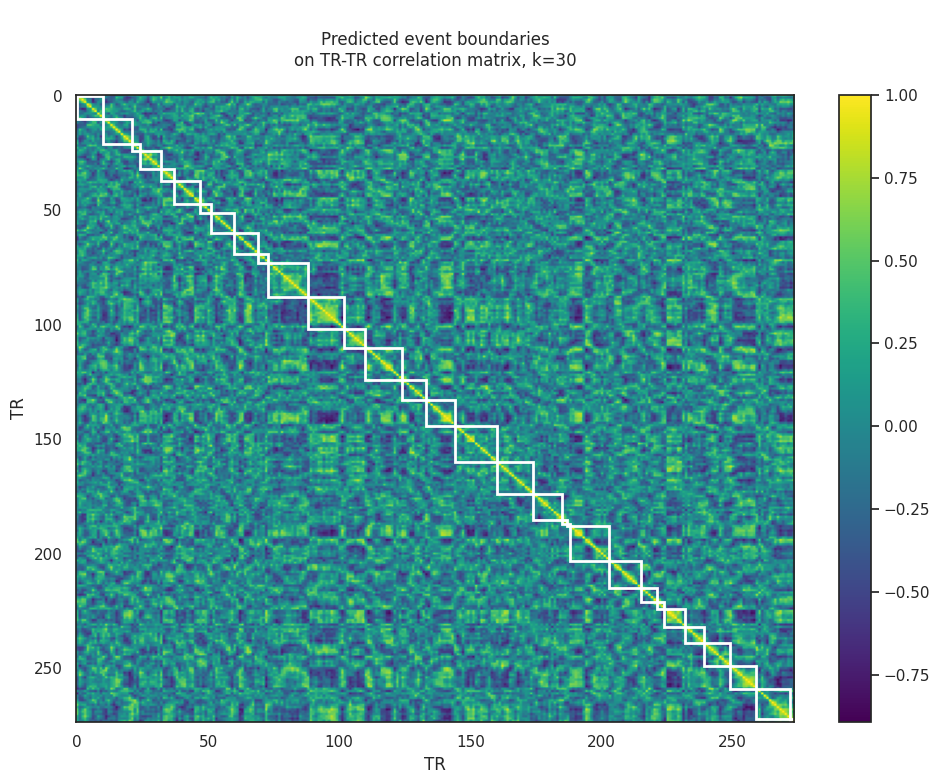

In [72]:
nTR = 274

#Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
title_text = f"""
Predicted event boundaries
on TR-TR correlation matrix, k={guess_k}
"""
img = plot_tt_similarity_matrix(fig, ax, test_data, bounds, nTR, title_text)
fig.colorbar(img, ax=ax)
fig.tight_layout()
fig.show()

**TRANSCRIPT LOADING/LLM SURPRISAL EMBEDDINGS:**

In [ ]:
raise NotImplementedError()

In [ ]:
# Audio
audio_file = os.path.join(paths['audio'], f'milkyway{variant}_audio.wav')
print(f"Audio: {audio_file}")
print(f"Exists: {os.path.exists(audio_file)}")

# Plain transcript
transcript_file = os.path.join(paths['transcript'], f'milkyway{variant}_transcript.txt')
with open(transcript_file) as f:
    transcript = f.read()
print(f"\nTranscript ({len(transcript)} chars):")
print(transcript[:300], '...')

# Aligned transcript
def load_aligned_transcript(task, variant, aligner='whisperx'):
    search_dir = paths.get(aligner, paths['gentle'])
    # try variant-specific first, then fall back to task-level
    candidates = [
        os.path.join(search_dir, f'milkyway{variant}.json'),
        os.path.join(search_dir, f'{task}{variant}.json'),
        os.path.join(search_dir, f'milkyway{variant}_alignment.json'),
    ]
    for fpath in candidates:
        if os.path.exists(fpath):
            with open(fpath) as f:
                return json.load(f)
    # fallback: list what's actually there
    found = sorted(glob.glob(os.path.join(search_dir, f'*{variant}*')))
    if found:
        print(f"[INFO] Found via glob: {found[0]}")
        with open(found[0]) as f:
            return json.load(f) if found[0].endswith('.json') else f.read()
    print(f"[WARN] No aligned transcript found for variant '{variant}' in {search_dir}")
    return None

aligned = load_aligned_transcript(task, variant, aligner='whisperx')
print(f"\nAligned transcript type: {type(aligned)}")
if isinstance(aligned, dict):
    print(f"Keys: {list(aligned.keys())}")

In [ ]:
# Check all loaded subjects have the same shape
shapes = {sub: bold_imgs[sub].shape for sub in loaded}
unique_shapes = set(shapes.values())
if len(unique_shapes) == 1:
    print(f"All subjects have consistent shape: {unique_shapes.pop()}")
else:
    print(f"[WARN] Inconsistent shapes: {shapes}")

# Check TR consistency
trs = {sub: bold_hdrs[sub].get_zooms()[-1] for sub in loaded}
unique_trs = set(trs.values())
if len(unique_trs) == 1:
    print(f"TR consistent across subjects: {unique_trs.pop()}s")
else:
    print(f"[WARN] Inconsistent TRs: {trs}")

In [ ]:
class SpacyVectors(object):
    """
    A class for extracting static word embeddings from text using SpaCy.

    This class tokenizes the input text, processes it with a SpaCy model to obtain
    linguistic annotations and static word vectors (e.g., from word2vec-based models).
    It fits on a DataFrame containing text data and transforms it into embeddings.

    Attributes:
        modelname (str): The name of the SpaCy model to load (e.g., 'en_core_web_lg').
        nlp (spacy.Language): The loaded SpaCy model.
        word_col (str): The column name in the DataFrame containing the words/text.
        doc_ (spacy.tokens.Doc): The processed SpaCy document after fitting.
    """

    def __init__(
        self,
        *,
        modelname: str,
        word_column: str,
    ):
        """
        Initialize the SpacyVectors object.

        Args:
            modelname (str): Name of the SpaCy model to use for tokenization and embeddings.
            word_column (str): Name of the column in the DataFrame that contains the text/words.
        """
        self.modelname = modelname
        self.nlp = spacy.load(modelname)
        self.word_col = word_column
        self.doc_ = None

    def fit(self, df: pd.DataFrame, y=None) -> pd.DataFrame:
        """
        Fit the SpaCy model to the input DataFrame and add linguistic annotations.

        This method tokenizes the text, processes it with SpaCy to obtain part-of-speech tags,
        dependencies, lemmas, and sentence indices. It modifies the DataFrame in place by
        exploding tokens and adding new columns.

        Args:
            df (pd.DataFrame): Input DataFrame with a column specified by word_column.
            y: Ignored. For compatibility with sklearn-like interfaces.

        Returns:
            pd.DataFrame: Modified DataFrame with added columns: 'word_index', 'token',
                          'sentence_index', 'sp_tag', 'sp_pos', 'sp_dep', 'sp_lemma'.
        """
        df.insert(0, "word_index", df.index.values)
        df["token"] = df[self.word_col].apply(self.nlp.tokenizer)
        df = df.explode("token", ignore_index=True)

        words = [token.text for token in df["token"].tolist()]
        spaces = [True] * len(words)
        doc = Doc(self.nlp.vocab, words=words, spaces=spaces)
        self.doc_ = self.nlp(doc)

        sentence_lens = [len(s) for s in doc.sents]
        df["sentence_index"] = (
            np.repeat(np.arange(len(sentence_lens)), sentence_lens) + 1
        )

        df["sp_tag"] = [token.tag_ for token in doc]
        df["sp_pos"] = [token.pos_ for token in doc]
        df["sp_dep"] = [token.dep_ for token in doc]
        df["sp_lemma"] = [token.lemma_ for token in doc]

        return df

    def transform(self) -> np.ndarray:
        """
        Transform the fitted document into a matrix of word embeddings.

        Extracts the static vector embeddings for each token in the processed document.

        Returns:
            np.ndarray: Array of shape (n_tokens, n_features) containing the embeddings.
                        n_features depends on the SpaCy model (e.g., 300 for 'en_core_web_lg').
        """
        embeddings = np.stack([token.vector for token in self.doc_])
        return embeddings

In [ ]:
#Set transcript path
transcript_path = os.path.join(paths['gentle'], f'milkyway{variant}', 'align.csv')

#Define models
models = {
    'gpt2': {
        'name': 'gpt2',
        'n_layers': 12,
        'n_features': 768,
        'extract_layer': 8,
        'cache_dir': '/home/NEU480/datasets/transformers_cache',
    },
    # Uncomment to add comparison models:
    # 'gemma': {
    #     'name': 'google/gemma-3-1b-it',
    #     'n_layers': 18,
    #     'n_features': 1152,
    #     'extract_layer': 12,
    #     'cache_dir': '/home/NEU480/datasets/transformers_cache',
    # },
}

context_len = 16
batch_size  = 2
device      = 'cpu'

In [ ]:
# Load in transcript CSV file
transcript = pd.read_csv(
    transcript_path, header=None, names=["text", "word", "onset", "offset"]
)
transcript.ffill(inplace=True)
transcript.insert(0, 'word_index', transcript.index.values)
print(transcript.head())

Now, I will make a function to extract surprisal from the milkyway vodka transcript using a given model:

In [ ]:
def extract_surprisal(transcript_df, model_cfg, context_len=16, batch_size=2, device='cpu'):
    """
    For each word in transcript_df, extract:
      - surprisal:  -log2 P(word | context)
      - entropy:    uncertainty of the distribution
      - rank:       rank of correct word in sorted predictions
      - top_guess:  model's most likely word at that position
      - embedding:  hidden state at extract_layer

    Returns transcript_df with new columns added.
    """
    # Load model and tokenizer
    tokenizer = AutoTokenizer.from_pretrained(
        model_cfg['name'],
        add_prefix_space=True,
        local_files_only=True,
        cache_dir=model_cfg['cache_dir'],
    )
    model = AutoModelForCausalLM.from_pretrained(
        model_cfg['name'],
        local_files_only=True,
        cache_dir=model_cfg['cache_dir'],
    )
    model.eval()

    # Tokenize: each word may become multiple sub-tokens
    df = transcript_df.copy()
    df['token']    = df['text'].apply(tokenizer.tokenize)
    df             = df.explode('token', ignore_index=True)
    df['token_id'] = df['token'].apply(tokenizer.convert_tokens_to_ids)

    # Build sliding context matrix: shape (n_tokens, context_len+1)
    fill = tokenizer.pad_token_id or 0
    token_ids = df['token_id'].tolist()
    n = len(token_ids)
    data = torch.full((n, context_len + 1), fill, dtype=torch.long)
    for i in range(n):
        chunk = token_ids[max(0, i - context_len): i + 1]
        data[i, -len(chunk):] = torch.tensor(chunk)

    # Run model in batches
    loader = DataLoader(data, batch_size=batch_size, shuffle=False)

    all_surprisals  = []
    all_entropies   = []
    all_ranks       = []
    all_top_guesses = []
    all_embeddings  = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Running {model_cfg['name']}"):
            out    = model(batch.to(device), output_hidden_states=True)
            logits = out.logits          # (batch, seq, vocab)
            states = out.hidden_states   # tuple of (batch, seq, features)

            true_ids = batch[:, -1]
            brange   = list(range(len(true_ids)))

            # Probabilities at prediction position (second-to-last token predicts last)
            probs    = torch.softmax(logits[:, -2, :], dim=-1)

            # Surprisal: -log2(P(true word))
            true_p   = probs[brange, true_ids]
            surprisal = -torch.log2(true_p + 1e-10)

            # Entropy: H = -sum(p * log2(p))
            entropy  = torch.distributions.Categorical(probs=probs).entropy() / np.log(2)

            # Rank of true word
            order    = probs.argsort(descending=True)
            ranks    = torch.eq(order, true_ids.reshape(-1, 1)).nonzero()[:, 1]

            # Top guess
            top_guess = order[:, 0]

            # Embedding at chosen layer
            layer_state = states[model_cfg['extract_layer']][:, -1, :]

            all_surprisals.append(surprisal.numpy())
            all_entropies.append(entropy.numpy())
            all_ranks.append(ranks.numpy())
            all_top_guesses.append(top_guess.numpy())
            all_embeddings.append(layer_state.numpy())

    # Attach to token-level dataframe
    df['surprisal']  = np.concatenate(all_surprisals)
    df['entropy']    = np.concatenate(all_entropies)
    df['rank']       = np.concatenate(all_ranks)
    df['top_guess_id'] = np.concatenate(all_top_guesses)
    embeddings_mat   = np.vstack(all_embeddings)  # (n_tokens, features)

    # Decode top guess IDs to readable words
    df['top_guess'] = df['top_guess_id'].apply(
        lambda tid: tokenizer.decode([tid]).strip()
    )

    # Collapse sub-tokens back to word level by averaging
    word_level = (
        df.groupby('word_index')
          .agg(
              text=('text', 'first'),
              onset=('onset', 'first'),
              offset=('offset', 'last'),
              surprisal=('surprisal', 'mean'),
              entropy=('entropy', 'mean'),
              rank=('rank', 'mean'),
              top_guess=('top_guess', 'first'),
          )
          .reset_index()
    )

    # Average embeddings per original word
    word_embeddings = np.vstack([
        embeddings_mat[df['word_index'] == wi].mean(axis=0)
        for wi in word_level['word_index']
    ])

    return word_level, word_embeddings

Now, I will find these surprisal ratings using GPT-2 embeddings:

In [ ]:
#Find gpt2 embeddings
gpt2_words, gpt2_embeddings = extract_surprisal(
    transcript, models['gpt2'], context_len=context_len,
    batch_size=batch_size, device=device
)

print(gpt2_words[['text', 'onset', 'offset', 'surprisal', 'entropy', 'rank', 'top_guess']].head(10))

In [ ]:
#Plot to check
fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

axes[0].plot(gpt2_words['onset'], gpt2_words['surprisal'], lw=0.8, color='steelblue')
axes[0].set_ylabel('Surprisal (bits)')
axes[0].set_title('GPT-2 surprisal — milkyway vodka')

axes[1].plot(gpt2_words['onset'], gpt2_words['entropy'], lw=0.8, color='coral')
axes[1].set_ylabel('Entropy (bits)')
axes[1].set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

print(f"Embeddings shape: {gpt2_embeddings.shape}")  # should be (n_words, 768)